# Librerias

In [1]:
import os
import sqlite3
import warnings

import pandas as pd
import numpy  as np
import plotly.express         as px
import plotly.graph_objects   as go
from   plotly.subplots import make_subplots
from scipy  import stats
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from dotenv import load_dotenv


# Configuracion para el dataframe

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
warnings.filterwarnings('ignore')

# Rutas

In [4]:
ROOT = Path.cwd().parent

load_dotenv(ROOT / '.env')
DB_PATH = str(ROOT / 'db' / 'gaming_warehouse.db')
IMAGENES_PATH = str(ROOT / 'Imagenes') + '/'

# funciones

In [5]:
def query(sql):
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(sql, conn)

# llenar mis dataframes

In [6]:
df_juegos = query("""
    SELECT j.*
    FROM   CAT_Juego j
    WHERE  j.juego_id NOT IN (SELECT juego_id_dlc FROM REL_Juego_DLC)
      AND  j.id_steam IS NOT NULL
""")

steam_ids  = set(df_juegos['juego_id'])
itad_ids   = set(df_juegos['itad_id_texto'].dropna())

df_hist     = query("SELECT * FROM Hist_Precios_ITAD")
df_hist     = df_hist[df_hist['itad_id_texto'].isin(itad_ids)].reset_index(drop=True)
df_hist['fecha'] = pd.to_datetime(df_hist['fecha_unix'], unit='s')

df_actuales = query("SELECT * FROM Datos_Actuales_ITAD")
df_actuales = df_actuales[df_actuales['itad_id_texto'].isin(itad_ids)].reset_index(drop=True)

df_reviews  = query("SELECT * FROM Hist_Steam_Reviews")
df_reviews  = df_reviews[df_reviews['juego_id'].isin(steam_ids)].reset_index(drop=True)

df_generos   = query("""
    SELECT r.juego_id, GROUP_CONCAT(g.nombre, '|') AS generos
    FROM   REL_Juego_Genero r
    JOIN   CAT_Genero g ON r.genero_id = g.genero_id
    WHERE  r.juego_id IN (SELECT juego_id FROM CAT_Juego
                          WHERE  id_steam IS NOT NULL
                            AND  juego_id NOT IN (SELECT juego_id_dlc FROM REL_Juego_DLC))
    GROUP  BY r.juego_id
""")

df_etiquetas = query("""
    SELECT r.juego_id, GROUP_CONCAT(e.nombre, '|') AS etiquetas
    FROM   REL_Juego_Etiqueta r
    JOIN   CAT_Etiqueta e ON r.etiqueta_id = e.etiqueta_id
    WHERE  r.juego_id IN (SELECT juego_id FROM CAT_Juego
                          WHERE  id_steam IS NOT NULL
                            AND  juego_id NOT IN (SELECT juego_id_dlc FROM REL_Juego_DLC))
    GROUP  BY r.juego_id
""")

df_modos     = query("""
    SELECT r.juego_id, GROUP_CONCAT(m.nombre, '|') AS modos
    FROM   REL_Juego_Modo r
    JOIN   CAT_Modo_Juego m ON r.modo_id = m.modo_id
    WHERE  r.juego_id IN (SELECT juego_id FROM CAT_Juego
                          WHERE  id_steam IS NOT NULL
                            AND  juego_id NOT IN (SELECT juego_id_dlc FROM REL_Juego_DLC))
    GROUP  BY r.juego_id
""")

df_dlcs = query("SELECT * FROM REL_Juego_DLC")


In [7]:
print(f"CAT_Juego con id_steam: {len(df_juegos):,}")
print(f"Hist_Precios_ITAD : {len(df_hist):,}")
print(f"Datos_Actuales_ITAD : {len(df_actuales):,}")
print(f"Hist_Steam_Reviews : {len(df_reviews):,}")
print(f"itad_ids con historial : {df_hist['itad_id_texto'].nunique():,}")
print(f"juego_ids con reseñas : {df_reviews['juego_id'].nunique():,}")
print(f"juevos dlc :{len(df_dlcs):,}")

CAT_Juego con id_steam: 6,399
Hist_Precios_ITAD : 516,255
Datos_Actuales_ITAD : 6,389
Hist_Steam_Reviews : 550,692
itad_ids con historial : 6,250
juego_ids con reseñas : 5,468
juevos dlc :1,367


In [8]:
tablas = {
    'CAT_Juego' : df_juegos,
    'Hist_Precios_ITAD' : df_hist,
    'Datos_Actuales_ITAD' : df_actuales,
    'Hist_Steam_Reviews' : df_reviews,
    'Gneros' : df_generos,
    'Etiquetas' : df_etiquetas,
    'Modos' : df_modos,
    'dlc' : df_dlcs,
}

for nombre, df in tablas.items():
    print(f"{nombre}  {df.shape}")

CAT_Juego  (6399, 28)
Hist_Precios_ITAD  (516255, 6)
Datos_Actuales_ITAD  (6389, 8)
Hist_Steam_Reviews  (550692, 14)
Gneros  (6396, 2)
Etiquetas  (5661, 2)
Modos  (6398, 2)
dlc  (1367, 2)


In [9]:
print("Columnas Hist_Precios_ITAD :", df_hist.columns.tolist())
print("Columnas Datos_Actuales_ITAD:", df_actuales.columns.tolist())
print("Columnas CAT_Juego:", df_juegos.columns.tolist())
print("Columnas Hist_Steam_Reviews :", df_reviews.columns.tolist())

Columnas Hist_Precios_ITAD : ['itad_id_texto', 'precio_base', 'precio', 'descuento', 'fecha_unix', 'fecha']
Columnas Datos_Actuales_ITAD: ['itad_id_texto', 'precio_actual', 'precio_minimo', 'fecha_minimo', 'en_bundle', 'fecha_actualizacion', 'descuento_actual', 'expiry']
Columnas CAT_Juego: ['juego_id', 'id_igdb', 'id_steam', 'titulo', 'categoria', 'fecha_lanzamiento', 'resumen', 'historia', 'url_portada', 'puntuacion_igdb', 'conteo_votos_igdb', 'conteo_dlc', 'conteo_videos', 'hltb_historia_principal', 'hltb_historia_extra', 'hltb_completacionista', 'steam_price_initial', 'steam_price_final', 'steam_discount_percent', 'metacritic_score', 'recommendations_count', 'achievements_count', 'steam_languages', 'pc_requirements_json', 'itad_id_texto', 'hltb_idINTEGER', 'hltb_procesado', 'hltb_id']
Columnas Hist_Steam_Reviews : ['resena_id', 'juego_id', 'resena_texto', 'recomendado', 'votos_utiles', 'votos_graciosos', 'puntuacion_ponderada', 'minutos_al_resenar', 'minutos_totales', 'fecha_creaci

# Estatus del catalogo

## que tengo vacio

In [10]:
nulos = df_juegos.isnull().sum()
pct   = (nulos / len(df_juegos) * 100).round(1)

resumen_nulos = (pd.DataFrame({'nulos': nulos, 'pct': pct})
                   .query('nulos > 0')
                   .sort_values('pct', ascending=False))

print(f"Total juegos: {len(df_juegos):,}")
print(f"Columnas con nulos: {len(resumen_nulos)} / {df_juegos.shape[1]}\n")
print(resumen_nulos.to_string())

# se me fue hltb_idINTEGER
# lade tiempo de comletar tomaran un tiempo en llenarse
# metatric score solo un tercio llena
#  steam_languages,achievements_count,steam_discount_percent son casi 1 tercio nuos pero puede deberse aque no todos lo juegos estan en staeam ya que concide mas o menos con id_steam 

Total juegos: 6,399
Columnas con nulos: 14 / 28

                         nulos    pct
hltb_idINTEGER            6399 100.00
metacritic_score          3703  57.90
hltb_completacionista     1716  26.80
hltb_historia_extra       1702  26.60
hltb_historia_principal   1543  24.10
hltb_id                   1393  21.80
steam_languages             82   1.30
achievements_count          69   1.10
steam_price_initial         69   1.10
steam_discount_percent      69   1.10
pc_requirements_json        69   1.10
recommendations_count       69   1.10
itad_id_texto                8   0.10
fecha_lanzamiento            3   0.00


# que tenfo lleno en campos que me interesan

In [11]:
campos = {
    'IGDB score' : 'puntuacion_igdb',
    'Metacritic' : 'metacritic_score',
    'HLTB historia': 'hltb_historia_principal',
    'HLTB extra': 'hltb_historia_extra',
    'HLTB completacio.' : 'hltb_completacionista',
    'Steam precio': 'steam_price_initial',
    'Steam descuento': 'steam_discount_percent',
    'Recomendaciones' : 'recommendations_count',
    'Achievements' : 'achievements_count',
    'itad_id_texto' : 'itad_id_texto',
}

for nombre, col in campos.items():
    n_ok = df_juegos[col].notna().sum()
    pct= 100 * n_ok / len(df_juegos)
    print(f"{nombre} {pct:5.1f}%  ({n_ok:,})")


IGDB score 100.0%  (6,399)
Metacritic  42.1%  (2,696)
HLTB historia  75.9%  (4,856)
HLTB extra  73.4%  (4,697)
HLTB completacio.  73.2%  (4,683)
Steam precio  98.9%  (6,330)
Steam descuento  98.9%  (6,330)
Recomendaciones  98.9%  (6,330)
Achievements  98.9%  (6,330)
itad_id_texto  99.9%  (6,391)


## Distribución de categoría

In [12]:
print(df_juegos['categoria'].value_counts(dropna=False).to_string())

print(f"Total DLCs en REL_Juego_DLC : {len(df_dlcs):,}")
print(f"Juegos base con al menos 1 DLC: {df_dlcs['juego_id_principal'].nunique():,}")
print(f"DLCs promedio por juego: {len(df_dlcs)/df_dlcs['juego_id_principal'].nunique():.1f}")

sin_itad = df_juegos['itad_id_texto'].isna().sum()
print(f"Juegos sin itad_id_texto: {sin_itad:,}  ({100*sin_itad/len(df_juegos):.1f}%)")

df_juegos['fecha_lanzamiento'] = pd.to_datetime(df_juegos['fecha_lanzamiento'], errors='coerce')
print(f"Rango fechas lanzamiento: {df_juegos['fecha_lanzamiento'].min().year} – {df_juegos['fecha_lanzamiento'].max().year}")
print(f"Sin fecha de lanzamiento: {df_juegos['fecha_lanzamiento'].isna().sum():,}")


categoria
Juego principal            6041
Bundle                      129
Juego ampliado               66
Remasterización              65
Remake                       59
Port                         36
Expansión independiente       3
Total DLCs en REL_Juego_DLC : 1,367
Juegos base con al menos 1 DLC: 761
DLCs promedio por juego: 1.8
Juegos sin itad_id_texto: 8  (0.1%)
Rango fechas lanzamiento: 1980 – 2026
Sin fecha de lanzamiento: 3


## Graficar mis datos

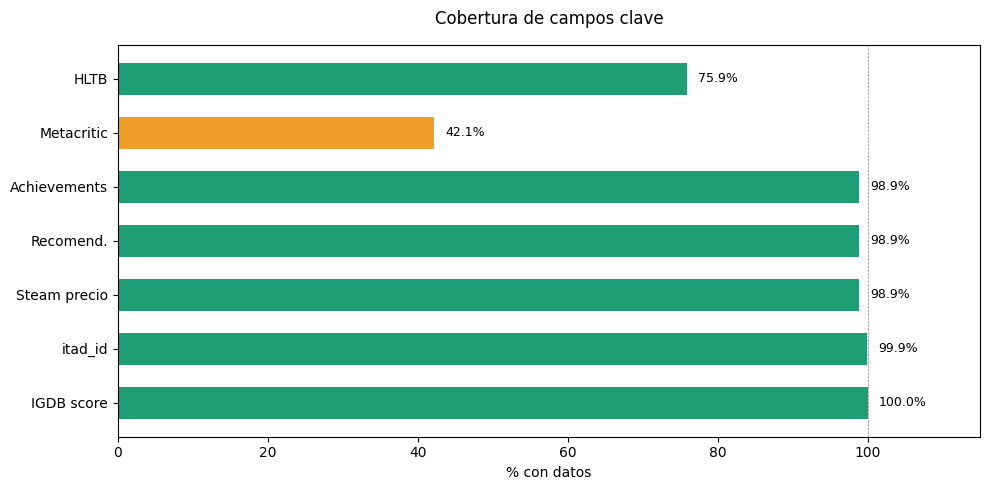

In [13]:
plt.figure(figsize=(10, 5))
campos_viz = {
    'IGDB score' : 'puntuacion_igdb',
    'itad_id' : 'itad_id_texto',
    'Steam precio' : 'steam_price_initial',
    'Recomend.' : 'recommendations_count',
    'Achievements' : 'achievements_count',
    'Metacritic' : 'metacritic_score',
    'HLTB' : 'hltb_historia_principal',
}

nombres = list(campos_viz.keys())
pcts    = [100 * df_juegos[c].notna().sum() / len(df_juegos) for c in campos_viz.values()]
colores = ['#1D9E75' if p >= 70 else ('#EF9F27' if p >= 30 else '#E24B4A') for p in pcts]

titulo="Cobertura de campos clave"

bars = plt.barh(nombres, pcts, color=colores, height=0.6)
plt.xlim(0, 115)
plt.xlabel('% con datos')
plt.title(titulo, fontsize=12, pad=15)
plt.axvline(100, color='gray', lw=0.5, ls='--')

for bar, pct in zip(bars, pcts):
    plt.text(pct + 1.5, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(IMAGENES_PATH +titulo+ '.png', dpi=150, bbox_inches='tight')
plt.show()

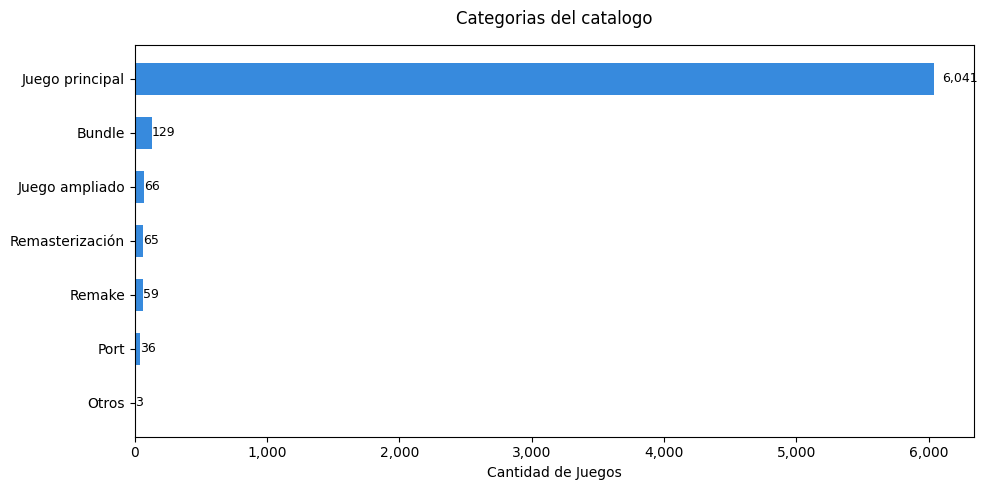

In [14]:
plt.figure(figsize=(10, 5))
cats = df_juegos['categoria'].value_counts()
cats_top = cats.head(6)
otros    = cats.iloc[6:].sum()
cats_plot = pd.concat([cats_top, pd.Series({'Otros': otros})])

titulo="Categorias del catalogo"
plt.barh(cats_plot.index[::-1], cats_plot.values[::-1], color='#378ADD', height=0.6)
plt.xlabel('Cantidad de Juegos')
plt.title(titulo, fontsize=12, pad=15)

# Formateador de miles
import matplotlib.ticker as mticker
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for i, v in enumerate(cats_plot.values[::-1]):
    plt.text(v + (v * 0.01), i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo +".png", dpi=150, bbox_inches='tight')
plt.show()

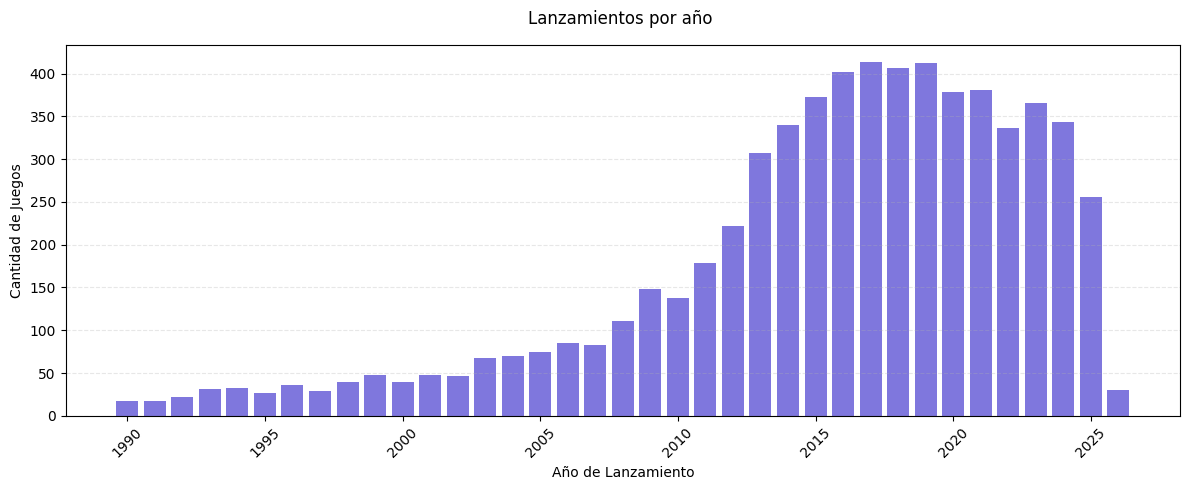

In [15]:
plt.figure(figsize=(12, 5))
por_anio = (df_juegos['fecha_lanzamiento'].dt.year
            .value_counts().sort_index())
por_anio = por_anio[(por_anio.index >= 1990) & (por_anio.index <= 2026)]

titulo="Lanzamientos por año "

plt.bar(por_anio.index, por_anio.values, color='#7F77DD', width=0.8)
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Cantidad de Juegos')
plt.title(titulo, fontsize=12, pad=15)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

## Clasicos describe

In [16]:
df_hist

,itad_id_texto,precio_base,precio,descuento,fecha_unix,fecha
0,018d937f-03e2-7281-a961-037a2d279a92,59.99,59.99,0,1741090525,2025-03-04 12:15:25
1,018d937f-03e2-7281-a961-037a2d279a92,29.99,29.99,0,1609872559,2021-01-05 18:49:19
2,018d937f-03e2-7281-a961-037a2d279a92,29.99,14.99,50,1608662061,2020-12-22 18:34:21
3,018d937f-03e2-7281-a961-037a2d279a92,29.99,29.99,0,1606847026,2020-12-01 18:23:46
4,018d937f-03e2-7281-a961-037a2d279a92,29.99,14.99,50,1606328860,2020-11-25 18:27:40
...,...,...,...,...,...,...
516250,018d937f-0998-7216-a664-200759cfec96,9.99,9.99,0,1471293922,2016-08-15 20:45:22
516251,018d937f-0998-7216-a664-200759cfec96,9.99,1.99,80,1470685527,2016-08-08 19:45:27
516252,018d937f-0998-7216-a664-200759cfec96,9.99,9.99,0,1467649526,2016-07-04 16:25:26
516253,018d937f-0998-7216-a664-200759cfec96,9.99,1.99,80,1466708003,2016-06-23 18:53:23


In [17]:
print(f"Registros totales: {len(df_hist):,}")
print(f"Juegos únicos (itad_id): {df_hist['itad_id_texto'].nunique():,}")
print(f"fecha minima: {df_hist['fecha'].min().date()}")
print(f"fecha maxima: {df_hist['fecha'].max().date()}")
print(f"Registros por juego (med.): {df_hist.groupby('itad_id_texto').size().median():.0f}")
print(f"Registros por juego (max): {df_hist.groupby('itad_id_texto').size().max():,}")
# sis e cumplio que nos tarajo al menos 10 años de datos

Registros totales: 516,255
Juegos únicos (itad_id): 6,250
fecha minima: 2016-06-01
fecha maxima: 2026-04-10
Registros por juego (med.): 82
Registros por juego (max): 319


## precio base

In [18]:
df_hist['precio_base'].describe().round(2)

count   516255.00
mean        18.42
std        113.58
min          0.00
25%          9.99
50%         14.99
75%         19.99
max      80000.00
Name: precio_base, dtype: float64

## precio

In [19]:
df_hist['precio'].describe().round(2)

# se tien con uno de 80000 que es claramente un error

count   516255.00
mean        12.73
std        111.96
min          0.00
25%          3.99
50%          9.99
75%         18.99
max      80000.00
Name: precio, dtype: float64

In [20]:
outliers = (df_hist[df_hist['precio_base'] >= 500][['itad_id_texto', 'precio_base']]
            .drop_duplicates()
            .merge(df_juegos[['itad_id_texto', 'id_steam', 'titulo','categoria']], on='itad_id_texto', how='left')
            .sort_values('precio_base', ascending=False))
display(outliers)

,itad_id_texto,precio_base,id_steam,titulo,categoria
0,018d937e-f4b9-7080-816b-cf6e33e64534,80000.00,582660,Black Desert,Juego principal
1,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,1920,Two Worlds,Juego principal
2,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1899.90,1920,Two Worlds,Juego principal
3,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1610.90,1920,Two Worlds,Juego principal


In [21]:
for itad_id, titulo in [
    ('018d937e-f4b9-7080-816b-cf6e33e64534', 'Black Desert'),
    ('018d937f-135f-72ac-b8b1-b8b94b9eae1e', 'Two Worlds')
    ]:
    print(f"{titulo}")
    print(df_hist[df_hist['itad_id_texto'] == itad_id]['precio_base'] .value_counts().sort_index().to_string())

Black Desert
precio_base
0.00          4
5.99          1
9.99        141
29.99         1
80000.00      1
Two Worlds
precio_base
4.00        1
280.00     22
399.98      4
1610.90     1
1899.90     1
1999.90    43


In [22]:
for itad_id, titulo in [
    ('018d937e-f4b9-7080-816b-cf6e33e64534', 'Black Desert'),
    ('018d937f-135f-72ac-b8b1-b8b94b9eae1e', 'Two Worlds')
]:
    sub = df_hist[df_hist['itad_id_texto'] == itad_id]['precio_base']
    print(f"{titulo}: min={sub.min():.2f}  median={sub.median():.2f}  max={sub.max():.2f}  valores únicos={sorted(sub.unique())[:10]}")

Black Desert: min=0.00  median=9.99  max=80000.00  valores únicos=[np.float64(0.0), np.float64(5.99), np.float64(9.99), np.float64(29.99), np.float64(80000.0)]
Two Worlds: min=4.00  median=1999.90  max=1999.90  valores únicos=[np.float64(4.0), np.float64(280.0), np.float64(399.98), np.float64(1610.9), np.float64(1899.9), np.float64(1999.9)]


In [23]:
PRECIO_MAX = 500
df_hist[df_hist['precio_base'] > PRECIO_MAX].reset_index(drop=True)

,itad_id_texto,precio_base,precio,descuento,fecha_unix,fecha
0,018d937e-f4b9-7080-816b-cf6e33e64534,80000.00,80000.00,0,1616421798,2021-03-22 14:03:18
1,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,280.00,86,1729876565,2024-10-25 17:16:05
2,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,229.60,89,1729531209,2024-10-21 17:20:09
3,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,28.00,99,1728666944,2024-10-11 17:15:44
4,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,78.40,96,1728321956,2024-10-07 17:25:56
5,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,280.00,86,1726075118,2024-09-11 17:18:38
6,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,229.60,89,1725729532,2024-09-07 17:18:52
7,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,28.00,99,1724865497,2024-08-28 17:18:17
8,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,78.40,96,1724519796,2024-08-24 17:16:36
9,018d937f-135f-72ac-b8b1-b8b94b9eae1e,1999.90,280.00,86,1722187100,2024-07-28 17:18:20


In [24]:
df_hist=df_hist[~df_hist['itad_id_texto'].isin([
    '018d937e-f4b9-7080-816b-cf6e33e64534',
    '018d937f-135f-72ac-b8b1-b8b94b9eae1e'
])].reset_index(drop=True)

In [25]:
df_hist.shape

(516035, 6)

In [26]:
df_hist['precio'].describe().round(2)
# aye sta mejor al edsvioancion estandar y el mximo

count   516035.00
mean        12.56
std         11.76
min          0.00
25%          3.99
50%          9.99
75%         18.99
max        269.99
Name: precio, dtype: float64

## descuento

In [27]:
df_hist['descuento'].describe().round(2)

count   516035.00
mean        30.73
std         34.23
min          0.00
25%          0.00
50%          0.00
75%         67.00
max        100.00
Name: descuento, dtype: float64

## Registros con descuento mayor a 0

In [28]:
con_desc = (df_hist['descuento'] > 0).sum()
print(f"\nRegistros con descuento > 0 : {con_desc:,} ({100*con_desc/len(df_hist):.1f}%)")



Registros con descuento > 0 : 254,463 (49.3%)


## juegos sin descuento

In [29]:
max_desc_por_juego = df_hist.groupby('itad_id_texto')['descuento'].max()
nunca_desc = (max_desc_por_juego == 0).sum()
print(f"Juegos sin ningún descuento : {nunca_desc:,}  ({100*nunca_desc/len(max_desc_por_juego):.1f}%)")

Juegos sin ningún descuento : 636  (10.2%)


## Distribución de descuento máximo por juego

In [30]:
bins = [0, 1, 20, 50, 75, 90, 101]
labs = ['0%', '1-19%', '20-49%', '50-74%', '75-89%', '90%+']
dist = pd.cut(max_desc_por_juego, bins=bins, labels=labs, right=False).value_counts().sort_index()
for label, n in dist.items():
    pct = 100 * n / len(max_desc_por_juego)
    print(f" {label:}  {n:,}  ({pct:.1f}%)")


 0%  636  (10.2%)
 1-19%  15  (0.2%)
 20-49%  553  (8.9%)
 50-74%  1,446  (23.1%)
 75-89%  2,311  (37.0%)
 90%+  1,287  (20.6%)


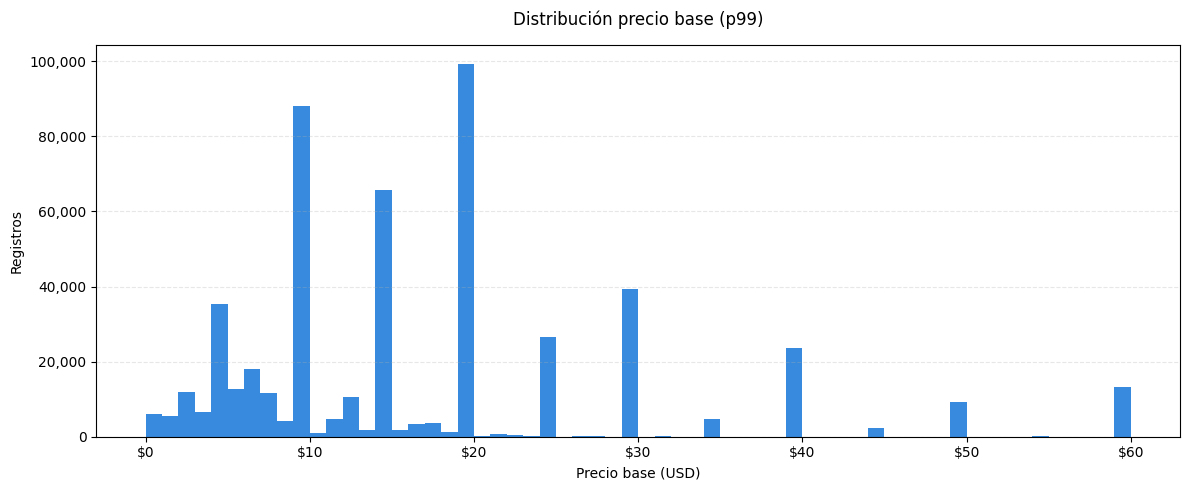

In [31]:
titulo = 'Distribución precio base (p99)'
p99 = df_hist['precio_base'].quantile(0.99)
datos = df_hist.loc[df_hist['precio_base'] <= p99, 'precio_base']

plt.figure(figsize=(12, 5))
plt.hist(datos, bins=60, color='#378ADD', edgecolor='none')
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Precio base (USD)')
plt.ylabel('Registros')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


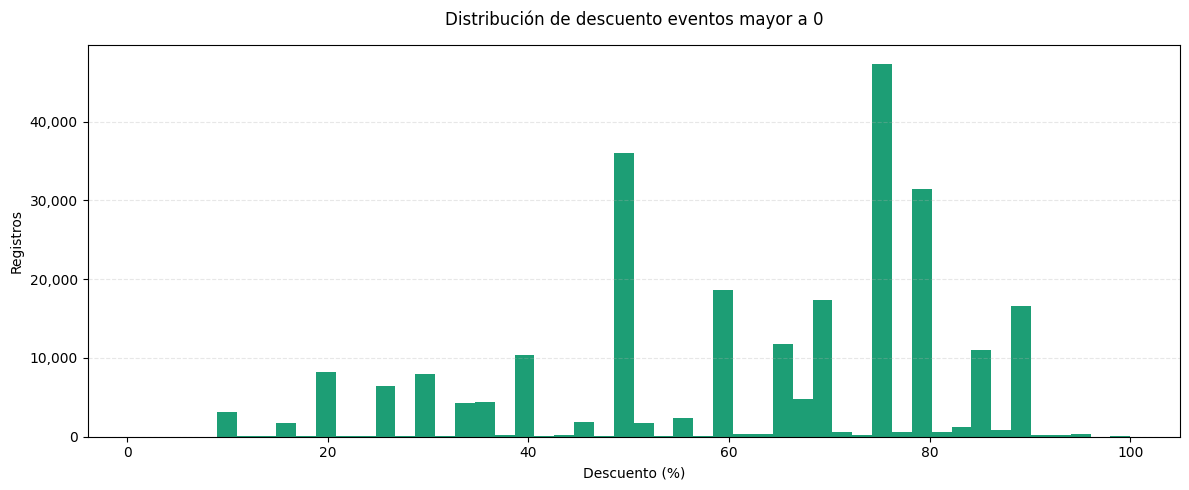

In [32]:
titulo = 'Distribución de descuento eventos mayor a 0'
desc_pos = df_hist.loc[df_hist['descuento'] > 0, 'descuento']

plt.figure(figsize=(12, 5))
plt.hist(desc_pos, bins=50, color='#1D9E75', edgecolor='none')
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Descuento (%)')
plt.ylabel('Registros')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


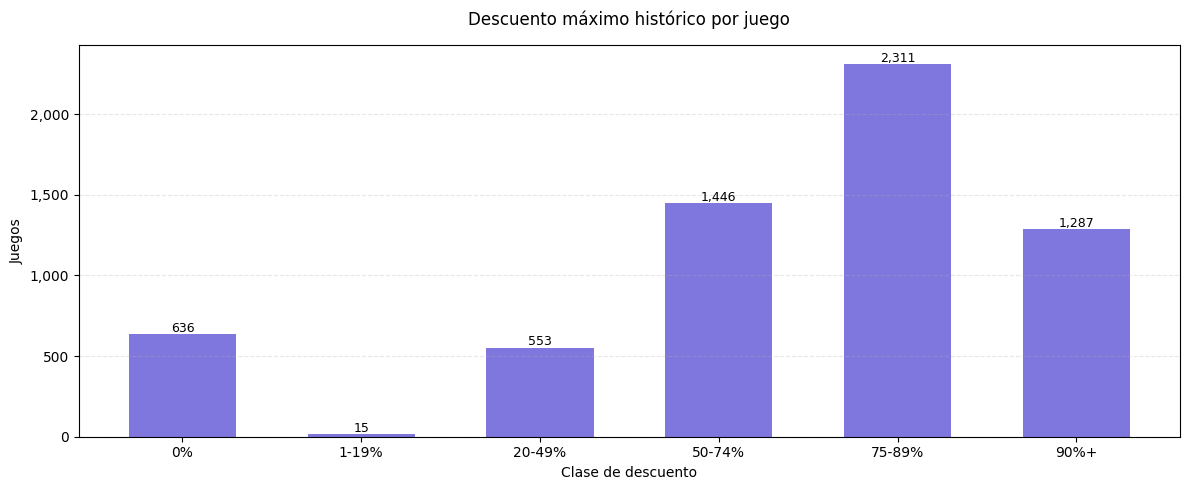

In [33]:
titulo = 'Descuento máximo histórico por juego'

plt.figure(figsize=(12, 5))
plt.bar(dist.index, dist.values, color='#7F77DD', width=0.6)
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Clase de descuento')
plt.ylabel('Juegos')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, (lab, v) in enumerate(dist.items()):
    plt.text(i, v + 15, f'{v:,}', ha='center', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


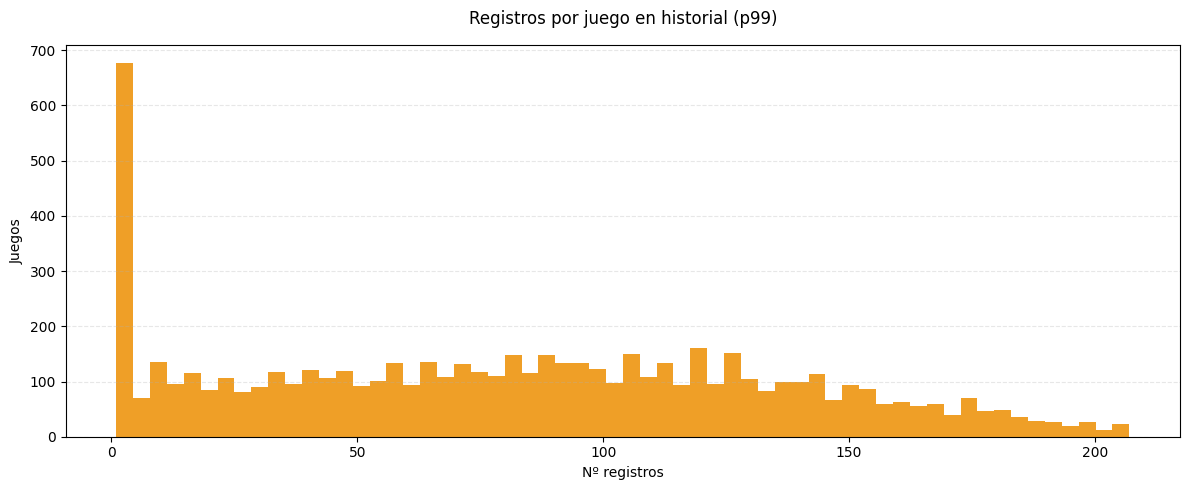

In [34]:
titulo = 'Registros por juego en historial (p99)'
regs_por_juego = df_hist.groupby('itad_id_texto').size()
p99r = regs_por_juego.quantile(0.99)

plt.figure(figsize=(12, 5))
plt.hist(regs_por_juego[regs_por_juego <= p99r], bins=60, color='#EF9F27', edgecolor='none')
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Nº registros')
plt.ylabel('Juegos')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


## analisis temportal

In [35]:
df_hist['anio'] = df_hist['fecha'].dt.year
df_hist['mes'] = df_hist['fecha'].dt.month
df_hist['anio_mes'] = df_hist['fecha'].dt.to_period('M')
df_hist['semana'] = df_hist['fecha'].dt.isocalendar().week.astype(int)

In [36]:
df_hist

,itad_id_texto,precio_base,precio,descuento,fecha_unix,fecha,anio,mes,anio_mes,semana
0,018d937f-03e2-7281-a961-037a2d279a92,59.99,59.99,0,1741090525,2025-03-04 12:15:25,2025,3,2025-03,10
1,018d937f-03e2-7281-a961-037a2d279a92,29.99,29.99,0,1609872559,2021-01-05 18:49:19,2021,1,2021-01,1
2,018d937f-03e2-7281-a961-037a2d279a92,29.99,14.99,50,1608662061,2020-12-22 18:34:21,2020,12,2020-12,52
3,018d937f-03e2-7281-a961-037a2d279a92,29.99,29.99,0,1606847026,2020-12-01 18:23:46,2020,12,2020-12,49
4,018d937f-03e2-7281-a961-037a2d279a92,29.99,14.99,50,1606328860,2020-11-25 18:27:40,2020,11,2020-11,48
...,...,...,...,...,...,...,...,...,...,...
516030,018d937f-0998-7216-a664-200759cfec96,9.99,9.99,0,1471293922,2016-08-15 20:45:22,2016,8,2016-08,33
516031,018d937f-0998-7216-a664-200759cfec96,9.99,1.99,80,1470685527,2016-08-08 19:45:27,2016,8,2016-08,32
516032,018d937f-0998-7216-a664-200759cfec96,9.99,9.99,0,1467649526,2016-07-04 16:25:26,2016,7,2016-07,27
516033,018d937f-0998-7216-a664-200759cfec96,9.99,1.99,80,1466708003,2016-06-23 18:53:23,2016,6,2016-06,25


## Registros por año

In [37]:
print(":")
print(df_hist.groupby('anio').size().to_string())
#una buena distribucion

:
anio
2016    21311
2017    28414
2018    35822
2019    45357
2020    50307
2021    53280
2022    54475
2023    60140
2024    69817
2025    73209
2026    23903


## Tasa de descuento por mes del año

In [38]:
desc_por_mes = (df_hist.groupby('mes')
                .agg(total=('descuento', 'count'),
                     con_desc=('descuento', lambda x: (x > 0).sum()))
                .assign(tasa=lambda d: (100 * d['con_desc'] / d['total']).round(1)))
print("Tasa de descuento por mes:")
print(desc_por_mes[['total', 'con_desc', 'tasa']].to_string())
#la estacionalidad es clara Junio al 78.6% es la Summer Sale de Steam,
#  diciembre al 66.2% es la Winter Sale, 
# octubre al 61% es la Halloween/Autumn Sale. 
# Todo tiene sentido

Tasa de descuento por mes:
     total  con_desc  tasa
mes                       
1    59766     15518 26.00
2    39037     17875 45.80
3    52838     26147 49.50
4    23412     12638 54.00
5    25045     11470 45.80
6    47700     37479 78.60
7    47431      8191 17.30
8    22929     10965 47.80
9    29270     16312 55.70
10   36479     22242 61.00
11   72045     35861 49.80
12   60083     39765 66.20


In [39]:
desc_por_semana = (df_hist[df_hist['descuento'] > 0]
                   .groupby('semana')['descuento']
                   .mean().round(1))
print(desc_por_semana.sort_values(ascending=False).head(50).to_string())
# de buenas a primera no veo un patron en las semanas

semana
9    64.30
50   64.30
3    64.20
24   64.20
30   64.20
40   63.60
8    63.60
2    63.40
49   63.40
10   63.40
1    63.30
36   63.30
15   63.20
21   63.20
41   63.10
12   63.00
34   62.90
11   62.90
5    62.80
25   62.70
29   62.70
51   62.70
46   62.50
26   62.50
48   62.40
32   62.40
14   62.30
22   62.30
23   62.30
16   62.30
52   62.20
38   62.10
20   62.10
4    62.00
37   61.90
42   61.80
28   61.70
33   61.70
31   61.60
47   61.40
45   61.30
17   61.30
6    61.30
19   61.30
39   61.20
35   61.20
7    61.10
13   61.10
18   61.00
44   60.80


## Graficas

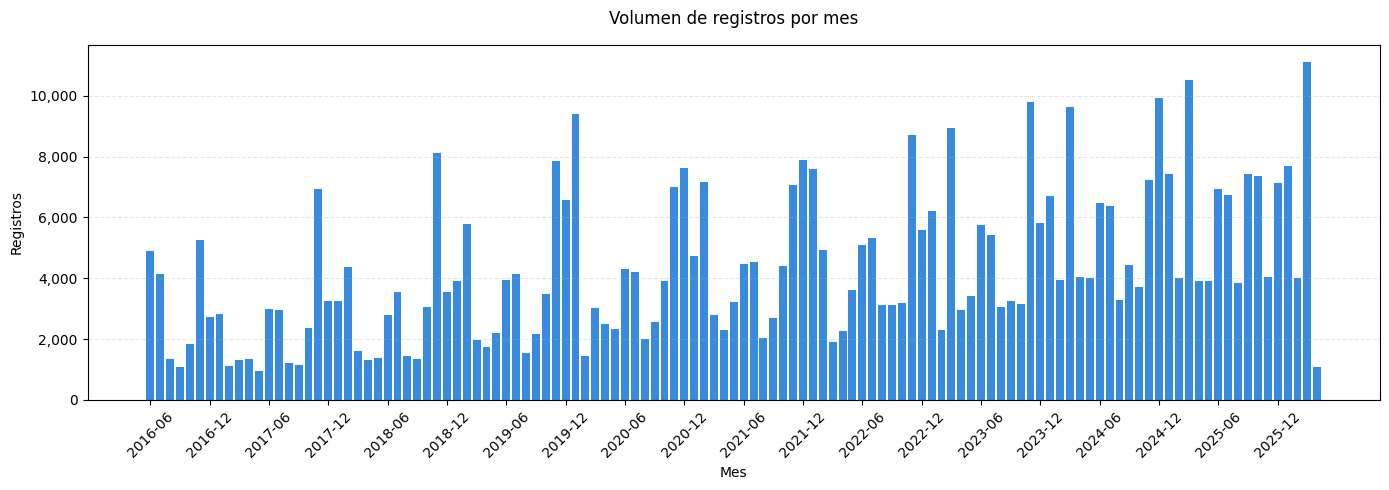

In [40]:
titulo = 'Volumen de registros por mes'
por_mes = df_hist.groupby('anio_mes').size().reset_index(name='registros')
por_mes['anio_mes_str'] = por_mes['anio_mes'].astype(str)

plt.figure(figsize=(14, 5))
plt.bar(range(len(por_mes)), por_mes['registros'], color='#378ADD', width=0.8)
plt.xticks(
    ticks=range(0, len(por_mes), 6),
    labels=por_mes['anio_mes_str'].iloc[::6],
    rotation=45
)
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Mes')
plt.ylabel('Registros')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


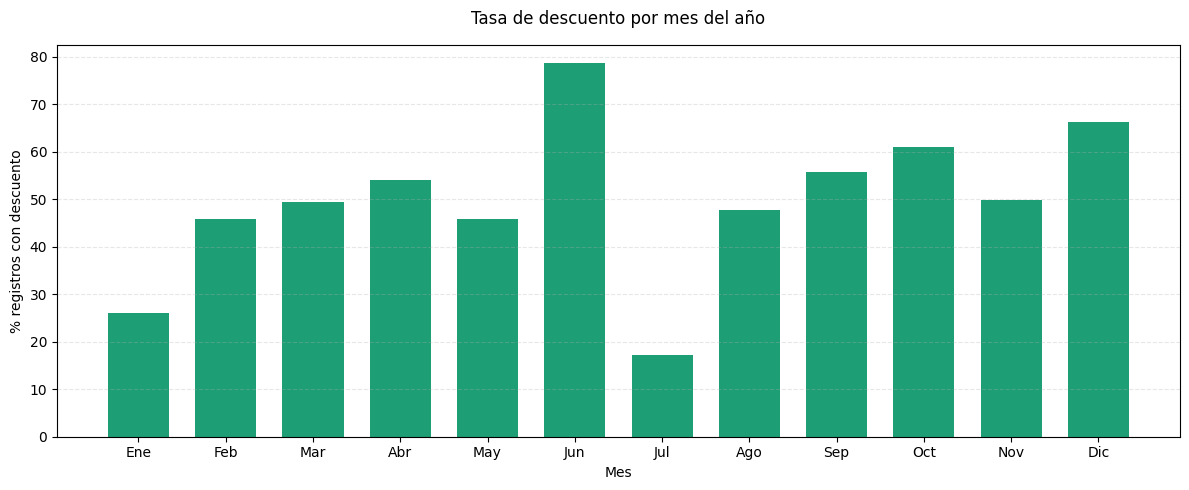

In [41]:
titulo = 'Tasa de descuento por mes del año'
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

plt.figure(figsize=(12, 5))
plt.bar(range(1, 13), desc_por_mes['tasa'], color='#1D9E75', width=0.7)
plt.xticks(range(1, 13), meses)
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Mes')
plt.ylabel('% registros con descuento')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


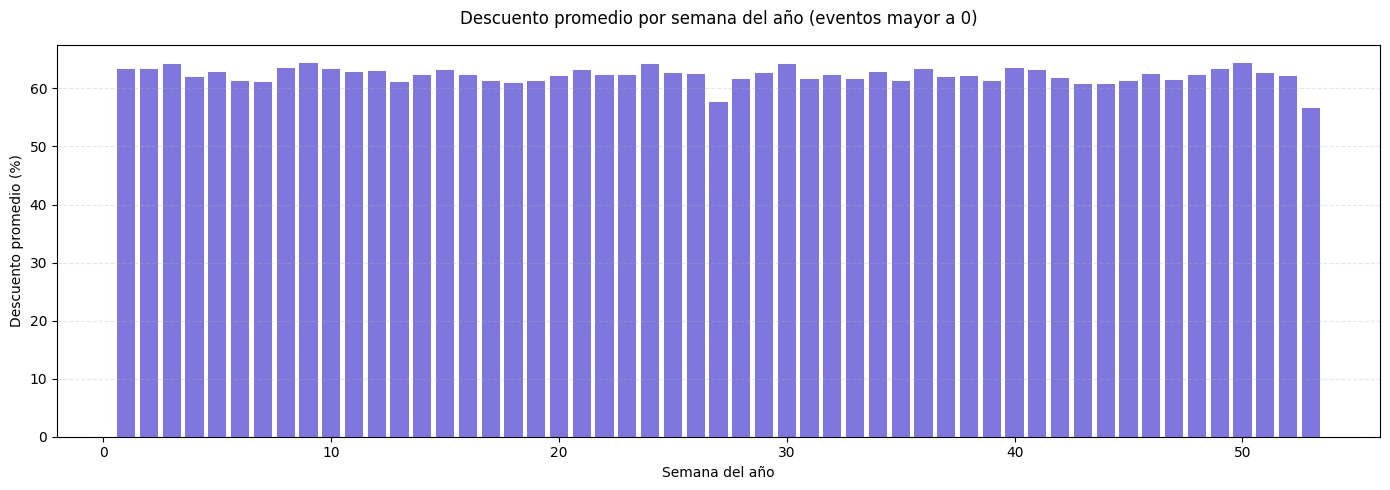

In [42]:
titulo = 'Descuento promedio por semana del año (eventos mayor a 0)'

plt.figure(figsize=(14, 5))
plt.bar(desc_por_semana.index, desc_por_semana.values, color='#7F77DD', width=0.8)
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Semana del año')
plt.ylabel('Descuento promedio (%)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


## valores actuales

In [43]:
df_actuales

,itad_id_texto,precio_actual,precio_minimo,fecha_minimo,en_bundle,fecha_actualizacion,descuento_actual,expiry
0,018d937f-03e2-7281-a961-037a2d279a92,NaN,NaN,NaN,0,1775855678,NaN,NaN
1,018d937f-1212-7232-b23f-a046f6fd4a57,39.99,3.99,1774545537.00,0,1775855680,0.00,NaN
2,018d937f-21e1-728e-86d7-9acb3c59f2bb,9.99,0.99,1774545492.00,0,1775855682,0.00,NaN
3,018d937f-2b23-73a3-9b40-d93860065d00,NaN,NaN,NaN,0,1775855684,NaN,NaN
4,018d937e-f829-73ff-aa7f-95421948da6b,NaN,NaN,NaN,0,1775855686,NaN,NaN
...,...,...,...,...,...,...,...,...
6384,018d937f-35ad-703d-b17c-09af001dda54,NaN,NaN,NaN,0,1775867231,NaN,NaN
6385,01939824-f7b2-7183-8ad2-5e836a78cebb,9.99,3.39,1774545988.00,0,1775867233,0.00,NaN
6386,018d937f-0c8e-70ea-a7db-dcfb5bca292a,5.99,0.89,1774545789.00,0,1775867234,0.00,NaN
6387,018d937f-24bf-70b0-9bff-ba584344516a,6.99,1.39,1774545495.00,0,1775867236,0.00,NaN


In [44]:
df_actuales.isnull().sum()


itad_id_texto             0
precio_actual           765
precio_minimo          1212
fecha_minimo            765
en_bundle                 0
fecha_actualizacion       0
descuento_actual        765
expiry                 5712
dtype: int64

In [45]:
100*df_actuales.isnull().mean()
#muchos de expiracion en 89 porque no estan en oferta ahora mismo

itad_id_texto          0.00
precio_actual         11.97
precio_minimo         18.97
fecha_minimo          11.97
en_bundle              0.00
fecha_actualizacion    0.00
descuento_actual      11.97
expiry                89.40
dtype: float64

In [46]:
df_actuales['fecha_actualizacion'] = pd.to_datetime(df_actuales['fecha_actualizacion'], unit='s', errors='coerce')
df_actuales['fecha_minimo'] = pd.to_datetime(df_actuales['fecha_minimo'], unit='s', errors='coerce')
df_actuales['expiry'] = pd.to_datetime(df_actuales['expiry'], unit='s', errors='coerce')

In [47]:
df_actuales

,itad_id_texto,precio_actual,precio_minimo,fecha_minimo,en_bundle,fecha_actualizacion,descuento_actual,expiry
0,018d937f-03e2-7281-a961-037a2d279a92,NaN,NaN,NaT,0,2026-04-10 21:14:38,NaN,NaT
1,018d937f-1212-7232-b23f-a046f6fd4a57,39.99,3.99,2026-03-26 17:18:57,0,2026-04-10 21:14:40,0.00,NaT
2,018d937f-21e1-728e-86d7-9acb3c59f2bb,9.99,0.99,2026-03-26 17:18:12,0,2026-04-10 21:14:42,0.00,NaT
3,018d937f-2b23-73a3-9b40-d93860065d00,NaN,NaN,NaT,0,2026-04-10 21:14:44,NaN,NaT
4,018d937e-f829-73ff-aa7f-95421948da6b,NaN,NaN,NaT,0,2026-04-10 21:14:46,NaN,NaT
...,...,...,...,...,...,...,...,...
6384,018d937f-35ad-703d-b17c-09af001dda54,NaN,NaN,NaT,0,2026-04-11 00:27:11,NaN,NaT
6385,01939824-f7b2-7183-8ad2-5e836a78cebb,9.99,3.39,2026-03-26 17:26:28,0,2026-04-11 00:27:13,0.00,NaT
6386,018d937f-0c8e-70ea-a7db-dcfb5bca292a,5.99,0.89,2026-03-26 17:23:09,0,2026-04-11 00:27:14,0.00,NaT
6387,018d937f-24bf-70b0-9bff-ba584344516a,6.99,1.39,2026-03-26 17:18:15,0,2026-04-11 00:27:16,0.00,NaT


In [48]:
print(f"Juegos en Datos_Actuales_ITAD : {len(df_actuales):,}")
print(f"Con descuento_actual > 0 : {(df_actuales['descuento_actual'] > 0).sum():,}  ({100*(df_actuales['descuento_actual'] > 0).mean():.1f}%)")
print(f"Con expiry definido : {df_actuales['expiry'].notna().sum():,}  ({100*df_actuales['expiry'].notna().mean():.1f}%)")

Juegos en Datos_Actuales_ITAD : 6,389
Con descuento_actual > 0 : 677  (10.6%)
Con expiry definido : 677  (10.6%)


## precio_actual

In [49]:
df_actuales['precio_actual'].describe().round(2)

count   5624.00
mean      15.73
std       14.48
min        0.00
25%        4.99
50%       12.49
75%       19.99
max      280.00
Name: precio_actual, dtype: float64

## precio_minimo

In [50]:
df_actuales['precio_minimo'].describe().round(2)

count   5177.00
mean       5.66
std        7.07
min        0.05
25%        1.49
50%        2.99
75%        6.99
max       86.38
Name: precio_minimo, dtype: float64

## descuento_actual

In [51]:
df_actuales['descuento_actual'].describe().round(2)

count   5624.00
mean       8.11
std       22.91
min        0.00
25%        0.00
50%        0.00
75%        0.00
max      100.00
Name: descuento_actual, dtype: float64

## juegos catuales en minimo historico

In [52]:
df_actuales['en_minimo'] = (df_actuales['precio_actual'] <= df_actuales['precio_minimo'] * 1.01).astype(int)
print(f" {df_actuales['en_minimo'].sum():,}  ({100*df_actuales['en_minimo'].mean():.1f}%)")

 517  (8.1%)


## hay juegos con 100 de descuento

In [53]:
df_actuales['diff_vs_minimo'] = ((df_actuales['precio_actual'] - df_actuales['precio_minimo'])
                                  / df_actuales['precio_minimo'].replace(0, np.nan) * 100).round(1)
print("\ndiff precio_actual vs precio_minimo (%):")
print(df_actuales['diff_vs_minimo'].describe().round(2))


diff precio_actual vs precio_minimo (%):
count    5177.00
mean      404.30
std       508.90
min      -100.00
25%       100.10
50%       300.70
75%       569.20
max     15684.20
Name: diff_vs_minimo, dtype: float64


In [54]:
fp = (df_actuales[(df_actuales['precio_actual'] == 0) & (df_actuales['precio_minimo'] > 0)]
      .merge(df_juegos[['itad_id_texto', 'id_steam', 'titulo', 'steam_price_initial']], 
             on='itad_id_texto', how='left')
      [['titulo', 'id_steam', 'precio_actual', 'precio_minimo', 'steam_price_initial']])
print(f"Juegos con precio_actual=0 y mínimo>0: {len(fp)}")
print(fp.to_string())

# son juegos que en su momento estaban gratis y leugo se hcicieron gratis Life is Strange, Team Fortress 2

Juegos con precio_actual=0 y mínimo>0: 121
                                                    titulo  id_steam  precio_actual  precio_minimo  steam_price_initial
0                                          Life is Strange    319630           0.00           1.99                 0.00
1                                          Team Fortress 2       440           0.00          19.99                 0.00
2                                                   Dota 2       570           0.00           7.49                 0.00
3                                               The Sims 4   1222670           0.00           4.79                 0.00
4                                                Destiny 2   1085660           0.00          34.99                 0.00
5                                      PUBG: Battlegrounds    578080           0.00          14.99                 0.00
6                                        Rainbow Six Siege    359550           0.00           3.99                 0.

In [55]:
mask_fp = df_actuales['precio_actual'] == 0
print(f"Juegos F2P (precio_actual=0): {mask_fp.sum()}")
df_actuales.loc[mask_fp, 'precio_minimo'] = 0

Juegos F2P (precio_actual=0): 568


In [56]:
mask_fp.value_counts()

precio_actual
False    5821
True      568
Name: count, dtype: int64

In [57]:
#sin minimo historico
sin_min = df_actuales[df_actuales['precio_minimo'].isna()]
print(f"Sin precio_minimo: {len(sin_min)}")
print(sin_min['precio_actual'].describe().round(2))
print(f"Con precio_actual = 0: {(sin_min['precio_actual'] == 0).sum()}")
print(f"Con precio_actual > 0: {(sin_min['precio_actual'] > 0).sum()}")

Sin precio_minimo: 765
count   0.00
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: precio_actual, dtype: float64
Con precio_actual = 0: 0
Con precio_actual > 0: 0


In [58]:
sin_min = df_actuales[df_actuales['precio_minimo'].isna()].merge(
    df_juegos[['itad_id_texto', 'id_steam', 'titulo', 'steam_price_initial']],
    on='itad_id_texto', how='left'
)
print(f"Sin precio_minimo: {len(sin_min)}")
print(f"Con steam_price_initial > 0: {(sin_min['steam_price_initial'] > 0).sum()}")
print(f"Con steam_price_initial = 0: {(sin_min['steam_price_initial'] == 0).sum()}")
print(f"Con steam_price_initial nulo: {sin_min['steam_price_initial'].isna().sum()}")
print(sin_min[['titulo', 'id_steam', 'precio_actual', 'precio_minimo', 'steam_price_initial']].to_string())

Sin precio_minimo: 765
Con steam_price_initial > 0: 168
Con steam_price_initial = 0: 537
Con steam_price_initial nulo: 60
                                                                            titulo  id_steam  precio_actual  precio_minimo  steam_price_initial
0                                                               Grand Theft Auto V    271590            NaN            NaN                 0.00
1                                                      The Elder Scrolls V: Skyrim     72850            NaN            NaN               359.00
2                                                    Grand Theft Auto: San Andreas     12120            NaN            NaN                 0.00
3                                                      Grand Theft Auto: Vice City     12110            NaN            NaN                 0.00
4                                                              Batman: Arkham City     57400            NaN            NaN                 0.00
5             

In [59]:
itad_sin_precio = set(df_actuales[df_actuales['precio_actual'].isna()]['itad_id_texto'])
#itad_sin_precio

In [60]:
con_hist = df_hist[df_hist['itad_id_texto'].isin(itad_sin_precio)]
print(f"se tiene de historial: {con_hist['itad_id_texto'].nunique()}")

se tiene de historial: 627


In [61]:
# prueba de uno detectado
df_juegos[df_juegos['titulo'].str.contains('Assassin', case=False, na=False)][['juego_id', 'id_steam', 'titulo', 'itad_id_texto', 'steam_price_initial']]

,juego_id,id_steam,titulo,itad_id_texto,steam_price_initial
10,11,33230,Assassin's Creed II,018d937f-3497-71d8-91b5-442e6b36f0cd,399.00
32,41,242050,Assassin's Creed IV Black Flag,018d937f-0602-72cd-b27e-1beaec4b9f6f,799.00
36,45,48190,Assassin's Creed Brotherhood,018d937f-0e82-70e5-ac00-0d05a4abc342,399.00
51,65,208480,Assassin's Creed III,018d937e-e9d4-7075-a482-728448f8f0fc,0.00
62,79,201870,Assassin's Creed Revelations,018d937f-0085-7156-93a8-5a7c9a7854cf,399.00
81,101,582160,Assassin's Creed Origins,018d937f-246a-7339-8ccc-7bddae738345,1199.00
101,128,289650,Assassin's Creed Unity,018d937e-f54c-7379-a57f-9ab6cdc42d20,599.00
102,129,812140,Assassin's Creed Odyssey,018d937f-0184-7248-8d64-3c723c523111,1199.00
120,160,368500,Assassin's Creed Syndicate,018d937e-fdd8-73fc-b6f2-669d6969f960,599.00
184,238,311560,Assassin's Creed Rogue,018d937e-f9bd-732a-8129-55703fce0e08,399.00


Se encontro el problema, al momento usar la api de itad uso el id para obtener el juego, pero esos juego ya no se venden por separado y viene normalemnte dentro de paquetes, itad regreso la informacion del juego original pero en steam ya no se venede solo, se vende en un paquete que ya tiene otro historial péro el id lo asocio. Entoncesmisma id pero diferente infroamcion en cada paltaforma estos se tiene que rellamar y revisar pero de momento se tendran que omitir

In [62]:
itad_sin_precio = set(df_actuales[df_actuales['precio_actual'].isna()]['itad_id_texto'])

In [63]:

juego_ids_sin_precio = set(df_juegos[df_juegos['itad_id_texto'].isin(itad_sin_precio)]['juego_id'])

df_juegos = df_juegos[~df_juegos['itad_id_texto'].isin(itad_sin_precio)].reset_index(drop=True)
df_hist = df_hist[~df_hist['itad_id_texto'].isin(itad_sin_precio)].reset_index(drop=True)
df_actuales= df_actuales[~df_actuales['itad_id_texto'].isin(itad_sin_precio)].reset_index(drop=True)
df_reviews= df_reviews[~df_reviews['juego_id'].isin(juego_ids_sin_precio)].reset_index(drop=True)
df_generos= df_generos[~df_generos['juego_id'].isin(juego_ids_sin_precio)].reset_index(drop=True)
df_etiquetas = df_etiquetas[~df_etiquetas['juego_id'].isin(juego_ids_sin_precio)].reset_index(drop=True)
df_modos= df_modos[~df_modos['juego_id'].isin(juego_ids_sin_precio)].reset_index(drop=True)

print(f"df_juegos: {len(df_juegos):,}")
print(f"df_hist: {len(df_hist):,}")
print(f"df_actuales : {len(df_actuales):,}")
print(f"df_reviews : {len(df_reviews):,}")

df_juegos: 5,634
df_hist: 492,906
df_actuales : 5,624
df_reviews : 506,676


## -Graficas

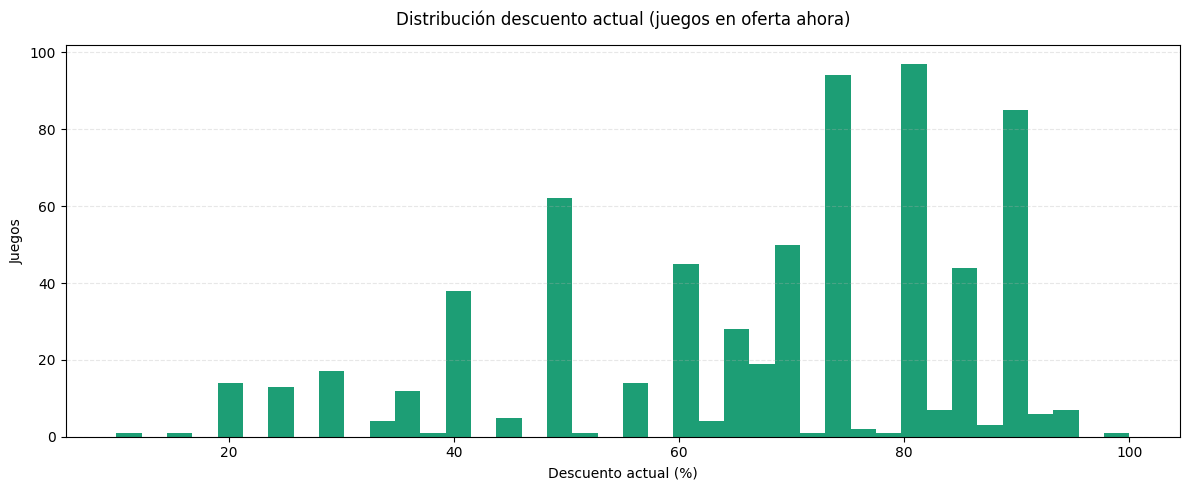

In [64]:
titulo = 'Distribución descuento actual (juegos en oferta ahora)'
desc_ahora = df_actuales[df_actuales['descuento_actual'] > 0]['descuento_actual']

plt.figure(figsize=(12, 5))
plt.hist(desc_ahora, bins=40, color='#1D9E75', edgecolor='none')
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Descuento actual (%)')
plt.ylabel('Juegos')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


In [65]:
hoy = pd.Timestamp.now()

In [66]:
(hoy - df_actuales['fecha_minimo']).dt.days

0       17
1       17
2       17
3        3
4       17
        ..
5619    17
5620    17
5621    17
5622    17
5623    17
Name: fecha_minimo, Length: 5624, dtype: int64

In [67]:
df_actuales['dias_desde_minimo'] = (hoy - df_actuales['fecha_minimo']).dt.days

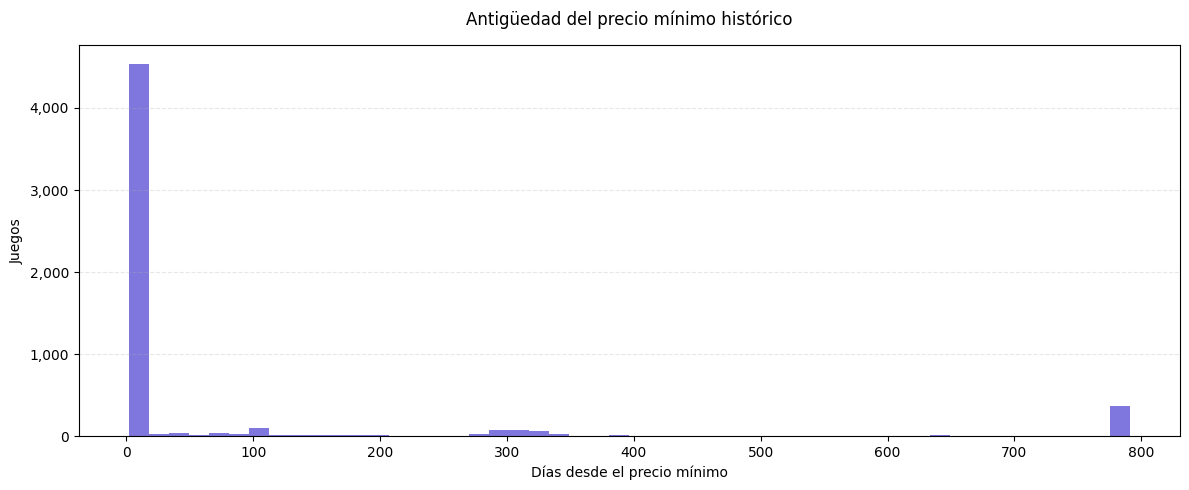

In [68]:
titulo = 'Antigüedad del precio mínimo histórico'
hoy = pd.Timestamp.now()
df_actuales['dias_desde_minimo'] = (hoy - df_actuales['fecha_minimo']).dt.days
dias = df_actuales['dias_desde_minimo'].dropna()
dias = dias[dias <= dias.quantile(0.99)]

plt.figure(figsize=(12, 5))
plt.hist(dias, bins=50, color='#7F77DD', edgecolor='none')
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Días desde el precio mínimo')
plt.ylabel('Juegos')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

#el pico gigante entre 0-30 días indica que ahce poco una serie de ofertas, posiblemnte de las spings sale

## decuentos y resenas

In [69]:
max_desc = (df_hist.groupby('itad_id_texto')
            .agg(
                desc_max=('descuento', 'max'),
                desc_avg=('descuento', 'mean'),
                n_eventos_desc=('descuento', lambda x: (x > 0).sum()),
                precio_base_med=('precio_base', 'median')
            ).reset_index())

reviews_agg = (df_reviews.groupby('juego_id')
               .agg(
                   total_resenas=('resena_id', 'count'),
                   pct_positivo=('recomendado', 'mean'),
                   avg_score_pond=('puntuacion_ponderada', 'mean'),
                   avg_minutos=('minutos_totales', 'median')
               ).reset_index()
               .assign(pct_positivo=lambda d: (d['pct_positivo'] * 100).round(2)))

df_corr = (df_juegos[['juego_id', 'itad_id_texto', 'titulo', 'puntuacion_igdb',
                       'conteo_votos_igdb', 'metacritic_score', 'fecha_lanzamiento',
                       'recommendations_count', 'achievements_count',
                       'conteo_dlc', 'steam_price_initial']]
           .merge(max_desc, on='itad_id_texto', how='left')
           .merge(reviews_agg, on='juego_id', how='left')
           .merge(df_generos, on='juego_id', how='left'))

In [70]:
df_corr['fecha_lanzamiento'] = pd.to_datetime(df_corr['fecha_lanzamiento'], errors='coerce')
df_corr['edad_dias'] = (pd.Timestamp.now() - df_corr['fecha_lanzamiento']).dt.days

In [71]:
print(f"Shape: {df_corr.shape}")
print(f"Nulos en desc_max: {df_corr['desc_max'].isna().sum()}")
print(df_corr[['desc_max', 'puntuacion_igdb', 'total_resenas', 'pct_positivo', 'edad_dias']].describe().round(2))

# EL SEGO POSITIVO SE MANITENE

Shape: (5634, 21)
Nulos en desc_max: 11
       desc_max  puntuacion_igdb  total_resenas  pct_positivo  edad_dias
count   5623.00          5634.00        4966.00       4966.00    5633.00
mean      65.38            71.37         102.03         88.69    3569.92
std       27.48            11.23         210.77         16.15    2571.37
min        0.00            10.27           1.00          0.00      12.00
25%       50.00            65.98           6.00         84.45    1678.00
50%       75.00            71.96          22.00         94.44    3118.00
75%       85.00            79.32          77.00        100.00    4630.00
max      100.00           100.00        1003.00        100.00   16538.00


In [72]:
cols_num = [
    'puntuacion_igdb', 'conteo_votos_igdb', 'metacritic_score',
    'recommendations_count', 'achievements_count', 'conteo_dlc',
    'steam_price_initial', 'total_resenas', 'pct_positivo',
    'avg_score_pond', 'avg_minutos', 'edad_dias', 'precio_base_med'
]

corr_pearson = {}
for col in cols_num:
    sub = df_corr[['desc_max', col]].dropna()
    r, p = stats.pearsonr(sub['desc_max'], sub[col])
    corr_pearson[col] = {'r': round(r, 3), 'p': round(p, 4), 'n': len(sub)}

df_corr_res = (pd.DataFrame(corr_pearson).T.sort_values('r', ascending=False))
print(df_corr_res.to_string())

# los dias que tiene le juego tien mucha relacioncon  decuentos mas agresivos
#  la relacion metatreric, pct, postivo, puntuacion de igdb
# p-value bajo nos dice que esos resultados no se deben al azar

                          r    p       n
edad_dias              0.26 0.00 5623.00
precio_base_med        0.23 0.00 5623.00
steam_price_initial    0.17 0.00 5616.00
conteo_votos_igdb      0.09 0.00 5623.00
puntuacion_igdb       -0.00 0.95 5623.00
recommendations_count -0.00 0.88 5616.00
conteo_dlc            -0.01 0.71 5623.00
achievements_count    -0.01 0.35 5616.00
avg_score_pond        -0.03 0.02 4965.00
total_resenas         -0.07 0.00 4965.00
pct_positivo          -0.08 0.00 4965.00
avg_minutos           -0.14 0.00 4965.00
metacritic_score      -0.20 0.00 2403.00


## graficas

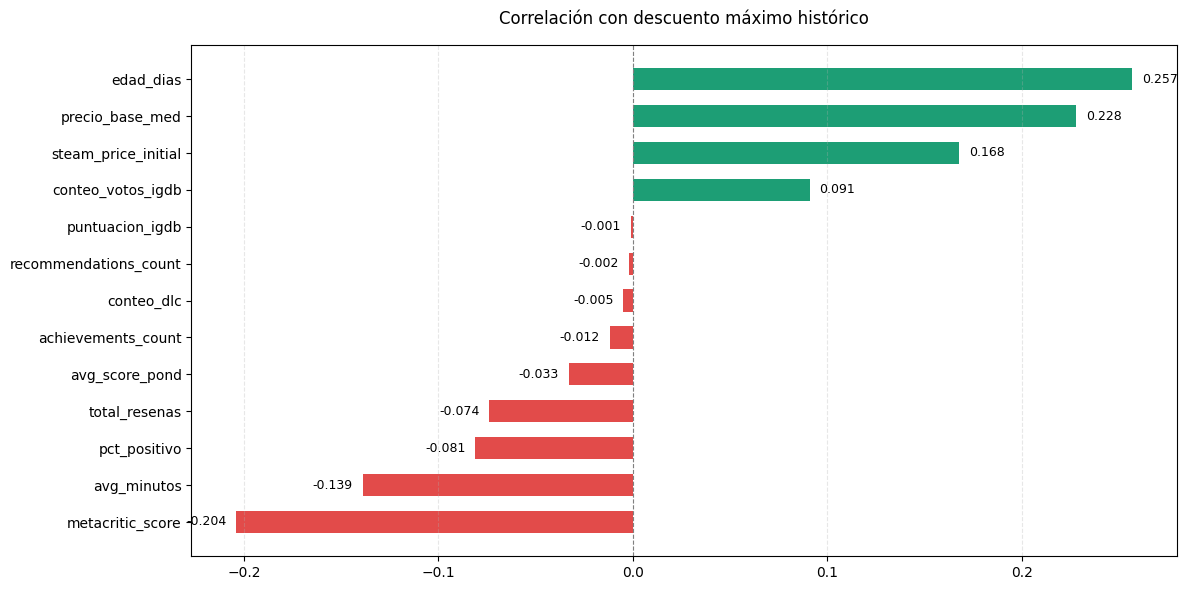

In [73]:
titulo = 'Correlación con descuento máximo histórico'
df_plot = df_corr_res.sort_values('r')
colores = ['#E24B4A' if r < 0 else '#1D9E75' for r in df_plot['r']]

plt.figure(figsize=(12, 6))
bars = plt.barh(df_plot.index, df_plot['r'], color=colores, height=0.6)
plt.axvline(0, color='gray', lw=0.8, ls='--')
plt.title(titulo, fontsize=12, pad=15)
for bar, (_, row) in zip(bars, df_plot.iterrows()):
    x = row['r']
    plt.text(x + (0.005 if x >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
             f"{x:.3f}", va='center', ha='left' if x >= 0 else 'right', fontsize=9)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


Descuento máximo por género (mediana):
                            mean  median  count
genero                                         
Puzzle                     70.30   80.00   1347
Racing                     73.80   80.00    244
Real Time Strategy (RTS)   71.80   80.00    232
Platform                   70.90   80.00    807
Sport                      67.50   80.00    195
Point-and-click            68.00   76.00    519
Arcade                     68.20   75.00    589
Adventure                  67.10   75.00   3405
Indie                      64.60   75.00   3225
Fighting                   68.90   75.00    233
Hack and slash/Beat 'em up 68.00   75.00    342
Music                      63.90   75.00    100
Strategy                   66.90   75.00   1324
Role-playing (RPG)         63.30   75.00   1566
Shooter                    67.80   75.00   1042
Simulator                  63.90   75.00   1317
Turn-based strategy (TBS)  68.40   75.00    312
Tactical                   67.70   75.00    304
C

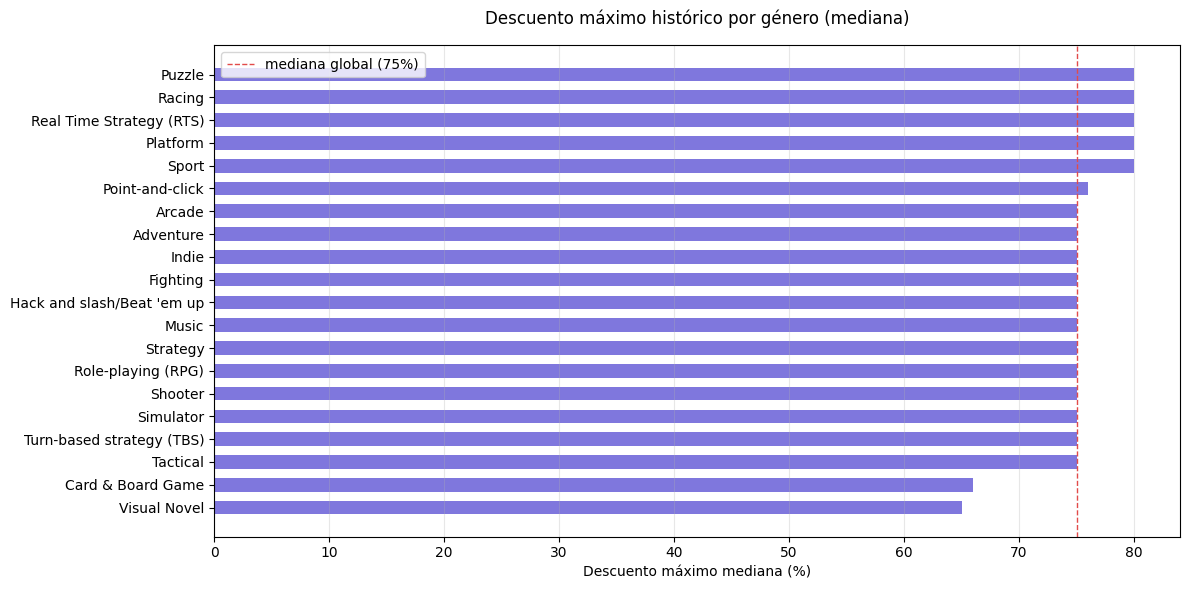

In [74]:
df_gen_exp = (df_corr[['juego_id', 'desc_max', 'generos']].dropna(subset=['generos'])
              .assign(genero=lambda d: d['generos'].str.split('|'))
              .explode('genero'))

desc_por_genero = (df_gen_exp.groupby('genero')['desc_max']
                   .agg(['mean', 'median', 'count'])
                   .query('count >= 50')
                   .sort_values('median', ascending=False)
                   .round(1))

print("Descuento máximo por género (mediana):")
print(desc_por_genero.to_string())

titulo = 'Descuento máximo histórico por género (mediana)'
plt.figure(figsize=(12, 6))
plt.barh(desc_por_genero.index[::-1], desc_por_genero['median'][::-1],
         color='#7F77DD', height=0.6)
plt.axvline(df_corr['desc_max'].median(), color='#E24B4A',
            lw=1, ls='--', label=f"mediana global ({df_corr['desc_max'].median():.0f}%)")
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Descuento máximo mediana (%)')
plt.legend()
plt.grid(axis='x', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()


  rango_precio  median  count
0         $0-5   40.00   1101
1        $5-10   80.00   1239
2       $10-20   77.00   1848
3       $20-30   75.00    752
4       $30-50   75.00    470
5         $50+   67.00    213


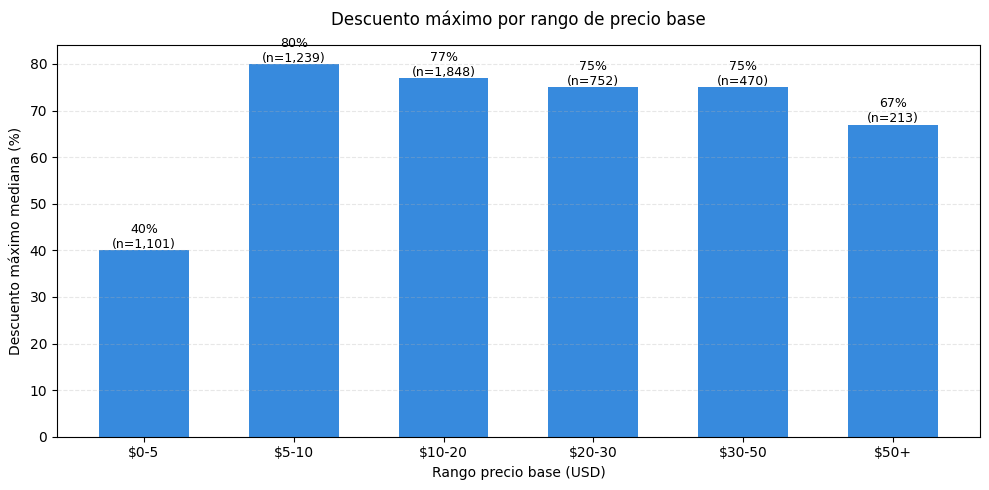

In [75]:
titulo = 'Descuento máximo por rango de precio base'
bins = [0, 5, 10, 20, 30, 50, 500]
labs = ['$0-5', '$5-10', '$10-20', '$20-30', '$30-50', '$50+']
df_corr['rango_precio'] = pd.cut(df_corr['precio_base_med'], bins=bins, labels=labs, right=False)

desc_precio = (df_corr.groupby('rango_precio', observed=True)['desc_max']
               .agg(['median', 'count']).reset_index())
print(desc_precio.to_string())

plt.figure(figsize=(10, 5))
plt.bar(desc_precio['rango_precio'].astype(str), desc_precio['median'],
        color='#378ADD', width=0.6)
plt.title(titulo, fontsize=12, pad=15)
plt.xlabel('Rango precio base (USD)')
plt.ylabel('Descuento máximo mediana (%)')
for i, row in desc_precio.iterrows():
    plt.text(i, row['median'] + 0.5, f"{row['median']:.0f}%\n(n={row['count']:,})",
             ha='center', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGENES_PATH + titulo + '.png', dpi=150, bbox_inches='tight')
plt.show()

# los de $50 bajan a 67%. Los juegos más caros descuentan menos agresivamente

# Notas de EDA

- se me fue hltb_idINTEGER
- lade tiempo de comletar tomaran un tiempo en llenarse
- metatric score solo un tercio llena
-  steam_languages,achievements_count,steam_discount_percent son casi 1 tercio nuos pero puede deberse aque no todos lo juegos estan en staeam ya que concide mas o menos con id_steam 
- el valor dematric esta mas lleno, nos servira
- El catálogo está dominado por juegos principales
- El pico de lanzamientos fue 2015-2019, con caída visible en 2020-2022 que es clara apndemia y recuperación en 2023-2024 pero 2025 volvio a bajar
- sis e cumplio que nos tarajo al menos 10 años de datos
- se tiene como precio maximo de 80000 que es claramente un error, se jsto opor que si fue un error de la base
- la estacionalidad es notable Junio al 78.6% es la Summer Sale de Steam,diciembre al 66.2% es la Winter Sale, octubre al 61% es la Halloween/Autumn Sale. Todo tiene sentido
- se ve un  congelamiento en julio depues de las ofertas de junio, en Enero bajo también por el mismo efecto de las ventas de invierno.
- Las desemana no dicen mucho, pero es curiosos que mantenga constante el promedio, es como si steam supiera cuantos porcentajes de edsceunto hacer
- actualemntwe los decusntos de 75%, 80% y 85% son los mas activos
- el pico gigante entre 0-30 días indica que ahce poco una serie de ofertas, posiblemnte de las spings sale
- los de $50 bajan a 67%. Los juegos más caros descuentan menos agresivamente

In [76]:
print(f"CAT_Juego con id_steam: {len(df_juegos):,}")
print(f"Hist_Precios_ITAD : {len(df_hist):,}")
print(f"Datos_Actuales_ITAD : {len(df_actuales):,}")
print(f"Hist_Steam_Reviews : {len(df_reviews):,}")
print(f"itad_ids con historial : {df_hist['itad_id_texto'].nunique():,}")
print(f"juego_ids con reseñas : {df_reviews['juego_id'].nunique():,}")
print(f"juevos dlc :{len(df_dlcs):,}")

CAT_Juego con id_steam: 5,634
Hist_Precios_ITAD : 492,906
Datos_Actuales_ITAD : 5,624
Hist_Steam_Reviews : 506,676
itad_ids con historial : 5,621
juego_ids con reseñas : 4,966
juevos dlc :1,367
